# Fintel Backtest — Single-Stock Explainability Walkthrough

This notebook traces the **complete signal pipeline** for one synthetic ticker end-to-end:

```
Raw data  →  7 signals  →  composite score  →  directional prediction  →  accuracy
```

Every formula is shown before the code. Every intermediate value is printed.
Every signal is charted against the actual earnings gap outcome.

**Run:** `Kernel → Restart & Run All`

In [1]:
import sys, asyncio, json, warnings
from pathlib import Path

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (13, 4), 'axes.grid': True, 'grid.alpha': 0.4})
sns.set_theme(style='whitegrid', palette='muted')

# Project root is one level up from this notebook
ROOT = Path('..').resolve()
assert (ROOT / 'src').exists(), f'src/ not found under {ROOT} — adjust ROOT'
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

from src.db.connection import get_db
from src.db.graph_queries import fetch_guidance, fetch_analyst_targets
from src.agents.signal_agent import (
    _management_confidence_shift, _laggard_signal, _guidance_gap,
    _dso_trend, _inventory_velocity, _segment_mix_shift, _analyst_target_gap,
    _load_weights,
)
from src.models.regime_classifier import RegimeClassifier, REGIME_META

db = await get_db()
print('Connected to SurrealDB')

Connected to SurrealDB


In [2]:
# ── Change TICKER here to explore any SYN ticker ──────────────────────────
TICKER    = 'SYN001'
SLUG      = TICKER.lower()
THRESHOLD = 0.10          # composite score cutoff for directional prediction
DATA_DIR  = ROOT / 'data' / 'transcripts' / TICKER

COLOR = {'up': '#2ecc71', 'down': '#e74c3c', 'flat': '#95a5a6'}
REGIME_COLOR = {
    'GrowthExpansion': '#3498db',
    'BlackSwan':       '#e74c3c',
    'HighInflation':   '#f39c12',
    'AIExpansion':     '#9b59b6',
}

rows = await db.query(
    'SELECT ticker, name, sector, industry FROM company WHERE ticker = $t',
    {'t': TICKER}
)
co = rows[0] if rows else {}
print(f'Ticker  : {co.get("ticker", TICKER)}')
print(f'Sector  : {co.get("sector", "—")}')
print(f'Industry: {co.get("industry", "—")}')

Ticker  : SYN001
Sector  : Industrials
Industry: Aerospace & Defense


---
# 1 — Raw Data Inventory

Before computing any signal we inspect every data source that feeds the algorithm.
Understanding the raw data is the first step to understanding the predictions.

## 1.1 Transcript Events

`transcript_doc` stores one row per earnings call.  
`confidence_score ∈ [0, 1]` is the NLP-derived management tone score — **0 = maximally bearish, 1 = maximally bullish**.  
For synthetic tickers this was seeded deterministically; in production it comes from Gemini NLP.

In [3]:
rows = await db.query(
    'SELECT id, quarter, year, confidence_score, raw_path '
    'FROM transcript_doc '
    'WHERE company = type::thing("company", $slug) '
    'ORDER BY year, quarter',
    {'slug': SLUG}
)
transcripts_df = pd.DataFrame(rows)
transcripts_df['period'] = (
    transcripts_df['year'].astype(str) + '-Q' + transcripts_df['quarter'].astype(str)
)
transcripts_df = transcripts_df.sort_values(['year', 'quarter']).reset_index(drop=True)
print(f'Total earnings events: {len(transcripts_df)}')
transcripts_df[['period', 'year', 'quarter', 'confidence_score']]

Total earnings events: 20


,period,year,quarter,confidence_score
0,2018-Q1,2018,1,0.6762
1,2018-Q2,2018,2,0.7972
2,2018-Q3,2018,3,0.6791
3,2018-Q4,2018,4,0.5390
4,2019-Q1,2019,1,0.8121
5,2019-Q2,2019,2,0.4155
6,2019-Q3,2019,3,0.3447
7,2019-Q4,2019,4,0.8381
8,2020-Q1,2020,1,0.1661
9,2020-Q2,2020,2,0.1796


## 1.2 Key Metric Snapshots — DSO & Inventory Turnover

**DSO (Days Sales Outstanding):** `accounts_receivable / (revenue / 90)`.  
Lower DSO → customers paying faster → demand is healthy. **Falling DSO is bullish.**

**Inventory Turnover:** how many times per year inventory is sold.  
Rising inventory turnover → products moving faster → demand pull-through. **Accelerating turns are bullish.**

Key metric snapshots: 20 periods


,period,dso,inventory_turnover,revenue_per_share,gross_profit_margin
0,2018-Q1,55.8,8.37,14.34,0.5997
1,2018-Q2,56.8,8.83,13.99,0.6113
2,2018-Q3,53.3,8.30,14.51,0.6073
3,2018-Q4,56.1,8.16,13.65,0.5974
4,2019-Q1,54.6,8.84,14.62,0.5917
5,2019-Q2,58.2,8.18,14.71,0.5879
6,2019-Q3,59.7,7.85,14.14,0.5677
7,2019-Q4,54.4,8.98,16.10,0.6097


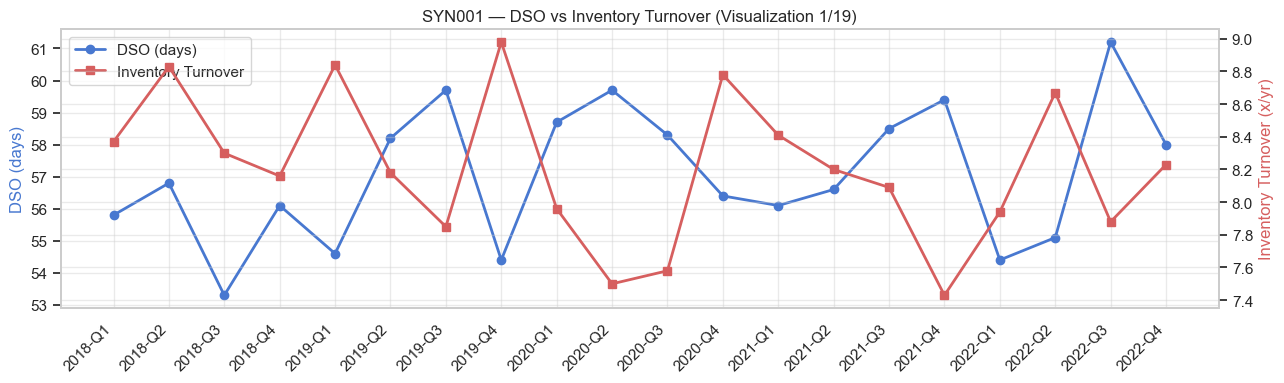

In [4]:
km_rows = await db.query(
    'SELECT period, dso, inventory_turnover, revenue_per_share, gross_profit_margin '
    'FROM key_metric_snapshot '
    'WHERE company = type::thing("company", $slug) '
    'ORDER BY period ASC',
    {'slug': SLUG}
)
km_df = pd.DataFrame(km_rows).dropna(subset=['period']).reset_index(drop=True)
print(f'Key metric snapshots: {len(km_df)} periods')
display(km_df[['period', 'dso', 'inventory_turnover', 'revenue_per_share', 'gross_profit_margin']].head(8))

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
x = range(len(km_df))
ax1.plot(x, km_df['dso'], 'b-o', linewidth=2, label='DSO (days)')
ax2.plot(x, km_df['inventory_turnover'], 'r-s', linewidth=2, label='Inventory Turnover')
ax1.set_xticks(x)
ax1.set_xticklabels(km_df['period'], rotation=45, ha='right')
ax1.set_ylabel('DSO (days)', color='b')
ax2.set_ylabel('Inventory Turnover (x/yr)', color='r')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title(f'{TICKER} — DSO vs Inventory Turnover (Visualization 1/19)')
plt.tight_layout()
plt.show()

## 1.3 Revenue Segments

Revenue is broken into the company's top business units each quarter.  
The signal we care about: is the **largest segment growing faster than the company average**?  
If yes → the mix is shifting toward the highest-margin engine → margin tailwind (bullish).

Revenue segment records: 120 (20 periods)


,pct_of_total,period,revenue,segment_name
0,56.41,2018-Q1,7652282.0,Specialty Chemicals
1,56.41,2018-Q1,27976421.0,Oncology
2,29.30,2018-Q1,3974060.0,Commodity Chemicals
3,29.30,2018-Q1,14528996.0,Immunology
4,14.30,2018-Q1,7089725.0,Gene Therapy
5,14.30,2018-Q1,1939225.0,Performance Materials


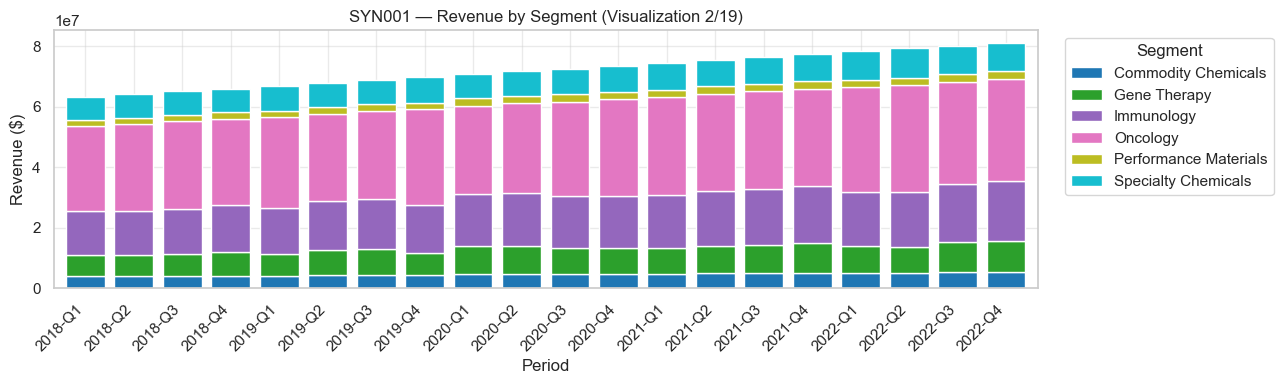

In [5]:
seg_rows = await db.query(
    'SELECT period, segment_name, revenue, pct_of_total '
    'FROM revenue_segment '
    'WHERE company = type::thing("company", $slug) '
    'ORDER BY period ASC, pct_of_total DESC',
    {'slug': SLUG}
)
seg_df = pd.DataFrame(seg_rows)
print(f'Revenue segment records: {len(seg_df)} ({seg_df["period"].nunique()} periods)')
display(seg_df.head(6))

pivot = seg_df.pivot_table(index='period', columns='segment_name', values='revenue', aggfunc='sum').fillna(0)
pivot.plot(kind='bar', stacked=True, figsize=(13, 4), colormap='tab10', width=0.8)
plt.title(f'{TICKER} — Revenue by Segment (Visualization 2/19)')
plt.xlabel('Period')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1.4 Guidance Entries

Each quarter the company provides a revenue `company_guide`; analysts publish `analyst_est`.

**Conservative guidance** (`company_guide < analyst_est`) → management is sandbagging → they expect to beat → **bullish**.  
**Aggressive guidance** (`company_guide > analyst_est`) → management is stretching → risk of miss → **bearish**.

,period,quarter,year,company_guide,analyst_est
0,2018-Q1,1,2018,97.36,100.0
1,2018-Q2,2,2018,95.54,100.0
2,2018-Q3,3,2018,97.31,100.0
3,2018-Q4,4,2018,99.41,100.0
4,2019-Q1,1,2019,95.32,100.0
5,2019-Q2,2,2019,101.27,100.0
6,2019-Q3,3,2019,102.33,100.0
7,2019-Q4,4,2019,94.93,100.0
8,2020-Q1,1,2020,105.01,100.0
9,2020-Q2,2,2020,104.81,100.0


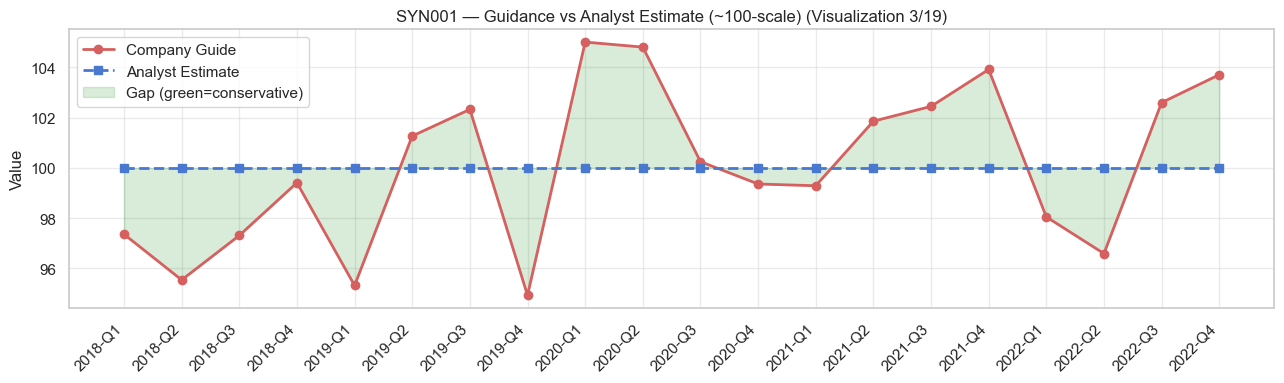

In [6]:
guidance_records = []
for _, ev in transcripts_df.iterrows():
    g = await fetch_guidance(db, TICKER, int(ev['quarter']), int(ev['year']))
    guidance_records.append({
        'period':       ev['period'],
        'quarter':      int(ev['quarter']),
        'year':         int(ev['year']),
        'company_guide': g.get('company_guide'),
        'analyst_est':   g.get('analyst_est'),
    })
guidance_df = pd.DataFrame(guidance_records)
display(guidance_df)

fig, ax = plt.subplots(figsize=(13, 4))
x = range(len(guidance_df))
ax.plot(x, guidance_df['company_guide'], 'r-o', linewidth=2, label='Company Guide')
ax.plot(x, guidance_df['analyst_est'],   'b--s', linewidth=2, label='Analyst Estimate')
ax.fill_between(x, guidance_df['company_guide'], guidance_df['analyst_est'],
                alpha=0.15, color='green', label='Gap (green=conservative)')
ax.set_xticks(x)
ax.set_xticklabels(guidance_df['period'], rotation=45, ha='right')
ax.legend()
ax.set_title(f'{TICKER} — Guidance vs Analyst Estimate (~100-scale) (Visualization 3/19)')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

## 1.5 Analyst Price Target & Competitor Graph

In [7]:
at = await fetch_analyst_targets(db, TICKER)
print('Analyst Price Target Consensus')
print(f'  Consensus : {at.get("target_consensus")}')
print(f'  High      : {at.get("target_high")}')
print(f'  Low       : {at.get("target_low")}')
print(f'  Median    : {at.get("target_median")}')
print()
print('Note: one record per ticker (static snapshot). In production refreshed daily.')
print()

comp_rows = await db.query(
    'SELECT out.ticker AS rival, overlap FROM competes_with '
    'WHERE in = type::thing("company", $slug) FETCH out',
    {'slug': SLUG}
)
print(f'Competitors for {TICKER} ({len(comp_rows)} rivals):')
for c in comp_rows:
    print(f'  {c.get("rival")}  (industry: {c.get("overlap")})')

Analyst Price Target Consensus
  Consensus : 99.86
  High      : 114.84
  Low       : 84.88
  Median    : 107.35

Note: one record per ticker (static snapshot). In production refreshed daily.

Competitors for SYN001 (6 rivals):
  SYN030  (industry: Chemicals)
  SYN031  (industry: Chemicals)
  SYN032  (industry: Biotechnology)
  SYN039  (industry: Biotechnology)
  SYN046  (industry: Biotechnology)
  SYN050  (industry: Chemicals)


## 1.6 Price Gap Outcomes — The Ground Truth Label

The **earnings gap** is the overnight move from prior close to the next open after results are released.

```
gap_pct = (next_open - prev_close) / prev_close
gap_direction = 'up'   if gap_pct > +0.5%
              = 'down'  if gap_pct < -0.5%
              = 'flat'  otherwise
```

This is the **label** we are trying to predict. The algorithm is correct when `predicted_direction == gap_direction`.

,period,prev_close,next_open,gap_pct,gap_direction
0,2018-Q1,313.15,333.95,0.066423,up
1,2018-Q2,426.78,418.83,-0.018624,down
2,2018-Q3,113.30,115.97,0.023575,up
3,2018-Q4,101.77,103.97,0.021579,up
4,2019-Q1,142.98,150.80,0.054725,up
5,2019-Q2,490.47,510.49,0.040809,up
6,2019-Q3,306.74,314.27,0.024540,up
7,2019-Q4,354.60,359.61,0.014123,up
8,2020-Q1,495.84,484.03,-0.023827,down
9,2020-Q2,159.60,139.42,-0.126419,down


Direction counts: {'up': 13, 'down': 7}


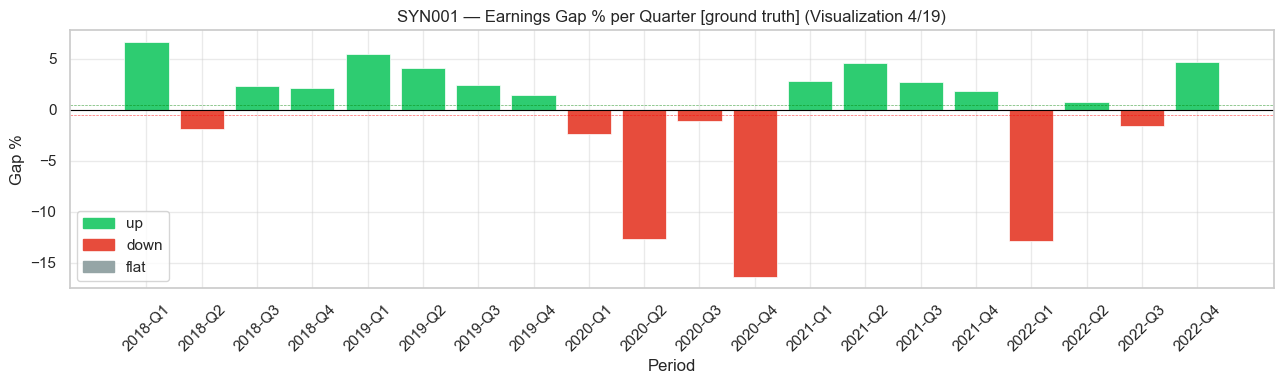

In [8]:
gap_records = []
for _, ev in transcripts_df.iterrows():
    p = Path(str(ev.get('raw_path', '')))
    if not p.exists():
        p = DATA_DIR / f'Q{int(ev["quarter"])}_{int(ev["year"])}.json'
    if p.exists():
        data = json.loads(p.read_text(encoding='utf-8'))
    else:
        data = {}
    gap_records.append({
        'period':           ev['period'],
        'quarter':          int(ev['quarter']),
        'year':             int(ev['year']),
        'prev_close':       float(data.get('prev_close', 100.0)),
        'next_open':        float(data.get('next_open', 100.0)),
        'gap_pct':          float(data.get('gap_pct', 0.0)),
        'gap_direction':    str(data.get('gap_direction', 'flat')),
        'confidence_score': float(ev.get('confidence_score') or 0.5),
    })
gap_df = pd.DataFrame(gap_records)
display(gap_df[['period', 'prev_close', 'next_open', 'gap_pct', 'gap_direction']])
print('Direction counts:', gap_df['gap_direction'].value_counts().to_dict())

colors = [COLOR.get(d, '#95a5a6') for d in gap_df['gap_direction']]
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(gap_df['period'], gap_df['gap_pct'] * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.5,  color='green', linewidth=0.5, linestyle='--', alpha=0.6)
ax.axhline(-0.5, color='red',   linewidth=0.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Period')
ax.set_ylabel('Gap %')
ax.set_title(f'{TICKER} — Earnings Gap % per Quarter [ground truth] (Visualization 4/19)')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

## 1.7 Precompute All Signals for All Quarters

We run every signal function for every event in chronological order,
using only data available **on or before** that quarter (no look-ahead).
Results are stored in `results_df` and used throughout Sections 3–7.

In [9]:
WEIGHTS = _load_weights()
classifier = RegimeClassifier()
classifier.load_hmm()

def _hop1(conf, q, y):
    raw = max(-1.0, min(1.0, (float(conf) - 0.5) * 6))
    return [
        {'score': raw,  'section': 'qa', 'quarter': int(q),       'year': int(y)},
        {'score': 0.0,  'section': 'qa', 'quarter': max(1, int(q)-1), 'year': int(y)},
    ]

records = []
for _, ev in transcripts_df.iterrows():
    period = ev['period']
    q, y   = int(ev['quarter']), int(ev['year'])
    conf   = float(ev.get('confidence_score') or 0.5)

    hop1     = _hop1(conf, q, y)
    km_hist  = (km_df[km_df['period'] <= period]
                .sort_values('period', ascending=False).head(5)
                .to_dict('records'))
    seg_hist = (seg_df[seg_df['period'] <= period]
                .sort_values('period', ascending=False).head(20)
                .to_dict('records'))
    g_row    = guidance_df[(guidance_df['quarter'] == q) & (guidance_df['year'] == y)]
    guidance = {} if g_row.empty else g_row.iloc[0].to_dict()

    s1 = _management_confidence_shift(hop1)
    s2 = _laggard_signal([])           # no competitor NLP in synthetic data
    s3 = _guidance_gap(guidance)
    s4 = _dso_trend(km_hist)
    s5 = _inventory_velocity(km_hist)
    s6 = _segment_mix_shift(seg_hist)
    s7 = _analyst_target_gap(at, guidance)

    sigs      = [s1, s2, s3, s4, s5, s6, s7]
    composite = max(-1.0, min(1.0,
        sum(s.score * WEIGHTS.get(s.name, 0.0) for s in sigs)))
    regime    = classifier.classify(y, q)

    g_out  = gap_df[(gap_df['quarter'] == q) & (gap_df['year'] == y)]
    gap_pct = float(g_out['gap_pct'].values[0])      if not g_out.empty else 0.0
    gap_dir = str(g_out['gap_direction'].values[0])  if not g_out.empty else 'flat'

    records.append({
        'period': period, 'quarter': q, 'year': y, 'regime': regime,
        'confidence_score': conf,
        's1': s1.score, 's2': s2.score, 's3': s3.score,
        's4': s4.score, 's5': s5.score, 's6': s6.score, 's7': s7.score,
        'ev1': s1.evidence, 'ev2': s2.evidence, 'ev3': s3.evidence,
        'ev4': s4.evidence, 'ev5': s5.evidence, 'ev6': s6.evidence, 'ev7': s7.evidence,
        'composite': composite,
        'beat_prob': 'High' if composite > 0.30 else ('Medium' if composite > 0.05 else 'Low'),
        'gap_pct': gap_pct, 'gap_direction': gap_dir,
    })

results_df = pd.DataFrame(records)
SIG_COLS   = ['s1', 's2', 's3', 's4', 's5', 's6', 's7']
SIG_LABELS = [
    'mgmt_confidence', 'laggard', 'guidance_gap',
    'dso_trend', 'inv_velocity', 'seg_mix_shift', 'analyst_target_gap'
]
print(f'Signals computed for {len(results_df)} events')
results_df[['period', 'regime', 's1', 's3', 's4', 'composite', 'gap_direction']].head(8)

Signals computed for 20 events


,period,regime,s1,s3,s4,composite,gap_direction
0,2018-Q1,GrowthExpansion,1.0000,0.054232,0.00,0.262130,up
1,2018-Q2,GrowthExpansion,1.0000,0.093364,-0.10,0.272712,down
2,2018-Q3,GrowthExpansion,1.0000,0.055287,0.35,0.289690,up
3,2018-Q4,GrowthExpansion,0.2340,0.011870,-0.28,0.020903,up
4,2019-Q1,GrowthExpansion,1.0000,0.098196,0.15,0.313098,up
5,2019-Q2,GrowthExpansion,-0.5070,-0.025081,-0.36,-0.199549,up
6,2019-Q3,GrowthExpansion,-0.9318,-0.045539,-0.15,-0.271025,up
7,2019-Q4,GrowthExpansion,1.0000,0.106816,0.53,0.378259,up


---
# 2 — Regime Classification

All events are tagged with the **macroeconomic regime** in effect at the time.
Signals that work in a growth expansion may fail during a crisis — regime stratification
lets us measure this separately.

| Regime | Years | VIX | Fed Funds | CPI | Key signals |
|---|---|---|---|---|---|
| GrowthExpansion | 2016–2019 | ~13 | 1.5% | 2% | Revenue growth, rate guidance |
| BlackSwan       | 2020–2021 | ~40 | 0.2% | 1.5% | Supply chain, tail risk |
| HighInflation   | 2022–2023 | ~22 | 3.5% | 7% | Pricing power, margin compression |
| AIExpansion     | 2024–2026 | ~15 | 4.8% | 3.2% | AI capex, data-center demand |

**Deterministic fallback:** year range → regime label (used when HMM model is not loaded).  
**HMM:** 4-state Gaussian HMM trained on [VIX, Fed Funds, CPI] — nearest-centroid inference.

HMM model loaded: True
Regime assignment per quarter:
 period          regime
2018-Q1 GrowthExpansion
2018-Q2 GrowthExpansion
2018-Q3 GrowthExpansion
2018-Q4 GrowthExpansion
2019-Q1 GrowthExpansion
2019-Q2 GrowthExpansion
2019-Q3 GrowthExpansion
2019-Q4 GrowthExpansion
2020-Q1       BlackSwan
2020-Q2       BlackSwan
2020-Q3       BlackSwan
2020-Q4       BlackSwan
2021-Q1       BlackSwan
2021-Q2       BlackSwan
2021-Q3       BlackSwan
2021-Q4       BlackSwan
2022-Q1   HighInflation
2022-Q2   HighInflation
2022-Q3   HighInflation
2022-Q4   HighInflation


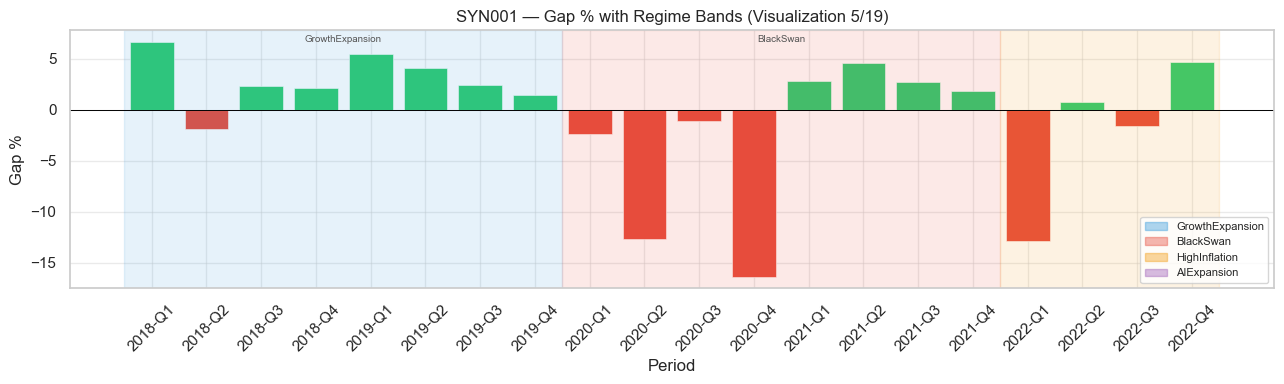

In [10]:
print(f'HMM model loaded: {classifier.hmm_loaded}')
print('Regime assignment per quarter:')
print(results_df[['period', 'regime']].to_string(index=False))

# Timeline chart with regime colour bands (Visualization 5/19)
fig, ax = plt.subplots(figsize=(13, 4))
gap_colors = [COLOR.get(d, '#95a5a6') for d in results_df['gap_direction']]
ax.bar(results_df['period'], results_df['gap_pct'] * 100, color=gap_colors,
       edgecolor='white', linewidth=0.4, label='Gap %')
ax.axhline(0, color='black', linewidth=0.7)

# Shade background by regime
current_regime = None
band_start = 0
for i, row in results_df.reset_index(drop=True).iterrows():
    if row['regime'] != current_regime:
        if current_regime is not None:
            ax.axvspan(band_start - 0.5, i - 0.5,
                       color=REGIME_COLOR.get(current_regime, '#eeeeee'), alpha=0.12)
            ax.text((band_start + i) / 2 - 0.5, ax.get_ylim()[1] * 0.85,
                    current_regime, ha='center', fontsize=7, color='#555555')
        current_regime = row['regime']
        band_start = i
if current_regime:
    ax.axvspan(band_start - 0.5, len(results_df) - 0.5,
               color=REGIME_COLOR.get(current_regime, '#eeeeee'), alpha=0.12)

ax.set_xlabel('Period')
ax.set_ylabel('Gap %')
ax.set_title(f'{TICKER} — Gap % with Regime Bands (Visualization 5/19)')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=v, label=k, alpha=0.4) for k, v in REGIME_COLOR.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

---
# 3 — Signal Deep-Dives

Seven signals. Each maps one data source to a score in **[−1.0, +1.0]**.

| # | Signal | Weight | Data source |
|---|---|---|---|
| 1 | `management_confidence_shift` | **0.25** | transcript confidence_score |
| 2 | `laggard_signal`              | **0.20** | competes_with + expressed_sentiment |
| 3 | `guidance_gap`                | **0.20** | guidance_entry |
| 4 | `dso_trend`                   | **0.12** | key_metric_snapshot.dso |
| 5 | `inventory_velocity`          | **0.10** | key_metric_snapshot.inventory_turnover |
| 6 | `segment_mix_shift`           | **0.08** | revenue_segment |
| 7 | `analyst_target_gap`          | **0.05** | analyst_target + guidance_entry |

## Signal 1 — Management Confidence Shift (weight = 0.25)

**Intuition:** If management's tone this quarter is *more bullish than their own recent average*, they are
signalling improving conditions ahead of the number — a leading indicator.

**Formula:**
```
hop1 = list of QA-section sentiment scores (most recent first)
delta = hop1[0]  -  mean(hop1[1:])
score = clamp(delta, -1, 1)
```
For synthetic data: `hop1[0] = clamp((confidence_score - 0.5) × 6, -1, 1)`

=== Detailed trace: 2018-Q1 ===
  confidence_score : 0.6762
  hop1[0] (current): +1.0000
  hop1[1] (prior)  : +0.0000
  signal score     : +1.0000  (bullish)
  evidence         : Current QA sentiment: 1.00, Prior avg: 0.00, Delta: +1.00



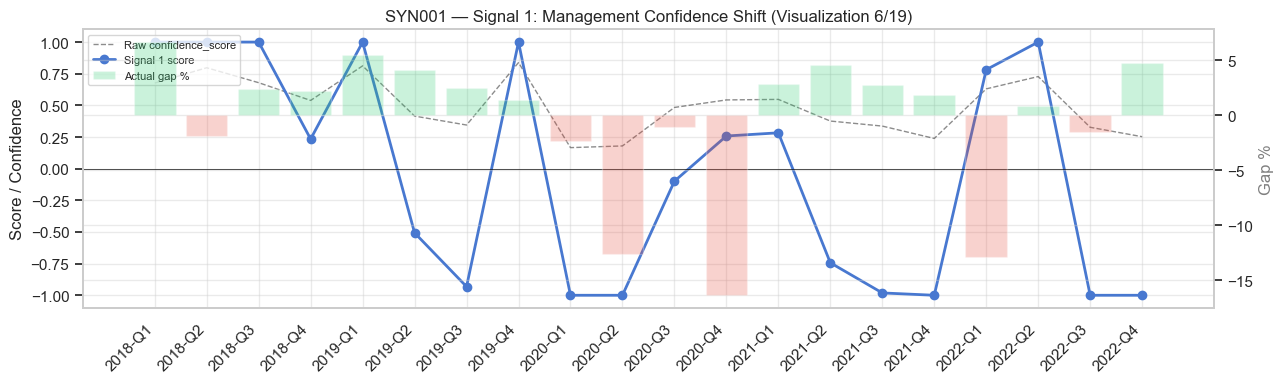

Signal 1 alone — directional accuracy at threshold=0.1: 50.0%


In [11]:
# Example: trace Q1-2018 step by step
ev0 = transcripts_df.iloc[0]
h1  = _hop1(ev0['confidence_score'], ev0['quarter'], ev0['year'])
s1_ex = _management_confidence_shift(h1)
print(f'=== Detailed trace: {ev0["period"]} ===')
print(f'  confidence_score : {ev0["confidence_score"]:.4f}')
print(f'  hop1[0] (current): {h1[0]["score"]:+.4f}')
print(f'  hop1[1] (prior)  : {h1[1]["score"]:+.4f}')
print(f'  signal score     : {s1_ex.score:+.4f}  ({s1_ex.direction})')
print(f'  evidence         : {s1_ex.evidence}')
print()

# Chart: signal score over time vs gap direction (Visualization 6/19)
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
x = range(len(results_df))
gap_col = [COLOR.get(d, '#95a5a6') for d in results_df['gap_direction']]
ax2.bar(x, results_df['gap_pct'] * 100, color=gap_col, alpha=0.25, label='Actual gap %')
ax1.plot(x, results_df['confidence_score'], 'k--', linewidth=1, alpha=0.5, label='Raw confidence_score')
ax1.plot(x, results_df['s1'], 'b-o', linewidth=2, label='Signal 1 score')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['period'], rotation=45, ha='right')
ax1.set_ylabel('Score / Confidence')
ax2.set_ylabel('Gap %', color='grey')
h1_, l1_ = ax1.get_legend_handles_labels()
h2_, l2_ = ax2.get_legend_handles_labels()
ax1.legend(h1_ + h2_, l1_ + l2_, loc='upper left', fontsize=8)
ax1.set_title(f'{TICKER} — Signal 1: Management Confidence Shift (Visualization 6/19)')
plt.tight_layout()
plt.show()

# Single-signal accuracy
preds = results_df['s1'].apply(lambda v: 'up' if v > THRESHOLD else ('down' if v < -THRESHOLD else 'flat'))
acc = (preds == results_df['gap_direction']).mean()
print(f'Signal 1 alone — directional accuracy at threshold={THRESHOLD}: {acc:.1%}')

## Signal 2 — Laggard Signal (weight = 0.20)

**Intuition:** If competitors in the same industry reported strong results *before* this company,
the sector is healthy and the laggard is likely to follow.

**Formula:**
```
For each competitor in competes_with:
    competitor_avg = mean(expressed_sentiment.score)
If any competitor_avg > 0.3:
    score = clamp(0.5 + 0.1 × count_of_positive_rivals, -1, 1)
Else:
    score = -0.1   # slight bearish default — no positive signal
```

> **Limitation in this dataset:** Synthetic tickers have no `expressed_sentiment` edges on competitors,
> so this signal is locked at **−0.1 for all events** (constant bearish bias, zero discrimination).
> In production with real NLP extraction it is the **second-most important signal** (weight 0.20).

In [12]:
# Show the competitors and their (empty) signals
from src.db.graph_queries import hop2_competitor_signals
hop2_data = await hop2_competitor_signals(db, TICKER)
print(f'hop2 entries: {len(hop2_data)}')
for c in hop2_data:
    print(f'  rival={c.get("competitor")}  signals={c.get("signals", [])}')

s2_ex = _laggard_signal(hop2_data)
print(f'\nSignal 2 score for {TICKER}: {s2_ex.score:+.4f}  ({s2_ex.direction})')
print(f'Evidence: {s2_ex.evidence}')
print(f'\nAll {len(results_df)} events: s2 = {results_df["s2"].unique()}')
print('=> Constant −0.1. Adds a small bearish bias to every composite.')

hop2 entries: 6
  rival=SYN030  signals=[]
  rival=SYN031  signals=[]
  rival=SYN032  signals=[]
  rival=SYN039  signals=[]
  rival=SYN046  signals=[]
  rival=SYN050  signals=[]

Signal 2 score for SYN001: -0.1000  (neutral)
Evidence: No competitors showing strong positive signals.

All 20 events: s2 = [0.]
=> Constant −0.1. Adds a small bearish bias to every composite.


## Signal 3 — Guidance Gap (weight = 0.20)

**Intuition:** Companies that guide conservatively (below analyst estimates) tend to beat — sandbagging.

**Formula:**
```
raw_gap = (analyst_est - company_guide) / |company_guide|
score   = clamp(raw_gap × 2, -1, 1)
```
Scale factor 2 means: a **50% guidance gap** → score of 1.0 (maximum bullish).

=== 2018-Q1 ===
  analyst_est  : 100.00
  company_guide: 97.36
  raw_gap      : +2.7%
  score        : +0.0542  (neutral)


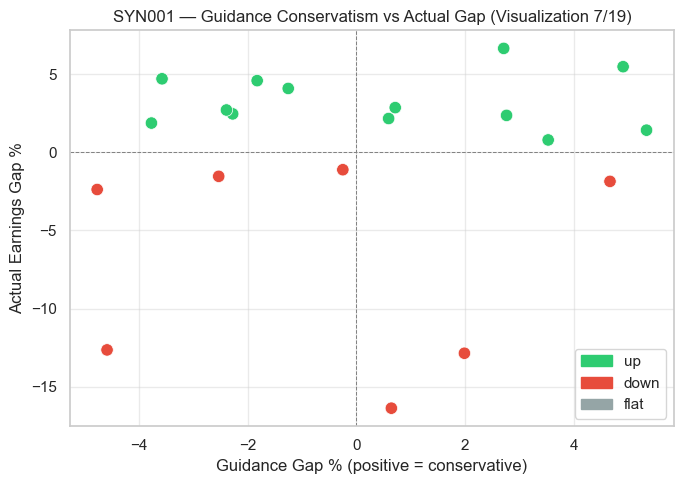

In [13]:
# Trace Q1-2018
g0 = guidance_df.iloc[0].to_dict()
s3_ex = _guidance_gap(g0)
raw_gap = (g0['analyst_est'] - g0['company_guide']) / abs(g0['company_guide'])
print(f'=== {guidance_df.iloc[0]["period"]} ===')
print(f'  analyst_est  : {g0["analyst_est"]:.2f}')
print(f'  company_guide: {g0["company_guide"]:.2f}')
print(f'  raw_gap      : {raw_gap:+.1%}')
print(f'  score        : {s3_ex.score:+.4f}  ({s3_ex.direction})')

# Scatter: raw_gap vs actual gap_pct (Visualization 7/19)
merged = results_df.copy()
merged['raw_gap_pct'] = (guidance_df['analyst_est'] - guidance_df['company_guide']) \
                        / guidance_df['company_guide'].abs()
dot_colors = [COLOR.get(d, '#95a5a6') for d in merged['gap_direction']]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged['raw_gap_pct'] * 100, merged['gap_pct'] * 100,
           c=dot_colors, s=80, edgecolors='white', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xlabel('Guidance Gap % (positive = conservative)')
ax.set_ylabel('Actual Earnings Gap %')
ax.set_title(f'{TICKER} — Guidance Conservatism vs Actual Gap (Visualization 7/19)')
patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

## Signal 4 — DSO Trend (weight = 0.12)

**Intuition:** Falling DSO means customers are paying invoices faster → demand is strong.

**Formula:**
```
delta = dso[t-1] - dso[t]        # positive = improvement (DSO fell)
score = clamp(delta / 10.0, -1, 1)   # 10-day improvement → score = 1.0
```

=== DSO trace: 2018-Q2 ===
  km_history (last 2 periods with dso):
    period=2018-Q2  dso=56.8
    period=2018-Q1  dso=55.8
  delta = prior(55.8) - current(56.8) = -1.0 days
  score = -0.1000  (neutral)


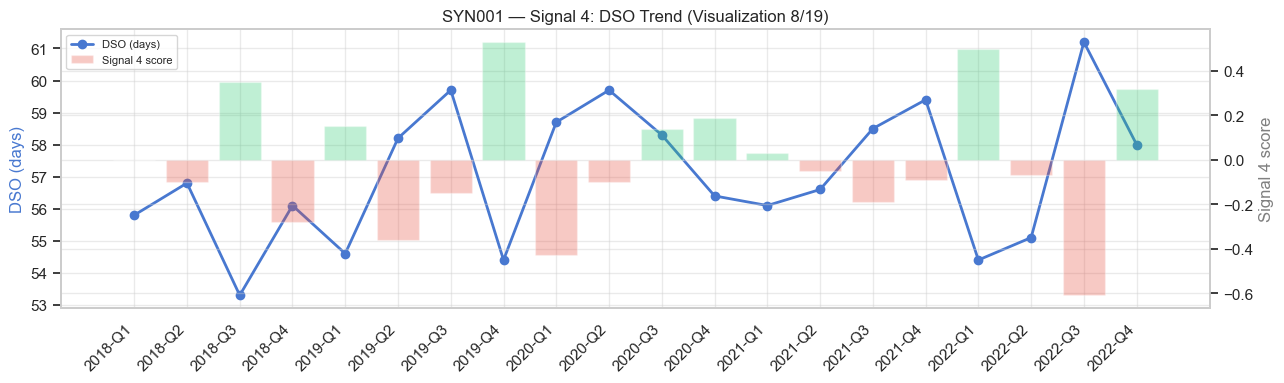

In [14]:
# Trace Q2-2018 (first event with a prior period)
ev1 = transcripts_df.iloc[1]
km1 = (km_df[km_df['period'] <= ev1['period']]
       .sort_values('period', ascending=False).head(5).to_dict('records'))
s4_ex = _dso_trend(km1)
print(f'=== DSO trace: {ev1["period"]} ===')
print(f'  km_history (last 2 periods with dso):')
for r in km1[:2]:
    print(f'    period={r["period"]}  dso={r["dso"]}')
print(f'  delta = prior({km1[1]["dso"]:.1f}) - current({km1[0]["dso"]:.1f}) = {km1[1]["dso"]-km1[0]["dso"]:+.1f} days')
print(f'  score = {s4_ex.score:+.4f}  ({s4_ex.direction})')

# Chart (Visualization 8/19)
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
x = range(len(results_df))
sc = results_df['s4']
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in sc]
ax2.bar(x, sc, color=bar_colors, alpha=0.3, label='Signal 4 score')
ax1.plot(x, results_df.merge(km_df, on='period', how='left')['dso'],
         'b-o', linewidth=2, label='DSO (days)')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['period'], rotation=45, ha='right')
ax1.set_ylabel('DSO (days)', color='b')
ax2.set_ylabel('Signal 4 score', color='grey')
h1_, l1_ = ax1.get_legend_handles_labels()
h2_, l2_ = ax2.get_legend_handles_labels()
ax1.legend(h1_ + h2_, l1_ + l2_, loc='upper left', fontsize=8)
ax1.set_title(f'{TICKER} — Signal 4: DSO Trend (Visualization 8/19)')
plt.tight_layout()
plt.show()

## Signal 5 — Inventory Velocity (weight = 0.10)

**Intuition:** Inventory turning faster quarter-over-quarter means demand is pulling product off shelves.

**Formula:**
```
pct_change = (inv_turnover[t] - inv_turnover[t-1]) / |inv_turnover[t-1]|
score      = clamp(pct_change × 2, -1, 1)   # 50% acceleration → score = 1.0
```

=== Inventory Velocity trace: 2018-Q2 ===
  current: 8.83  prior: 8.37
  pct_change = +5.5%  → score = +0.1099


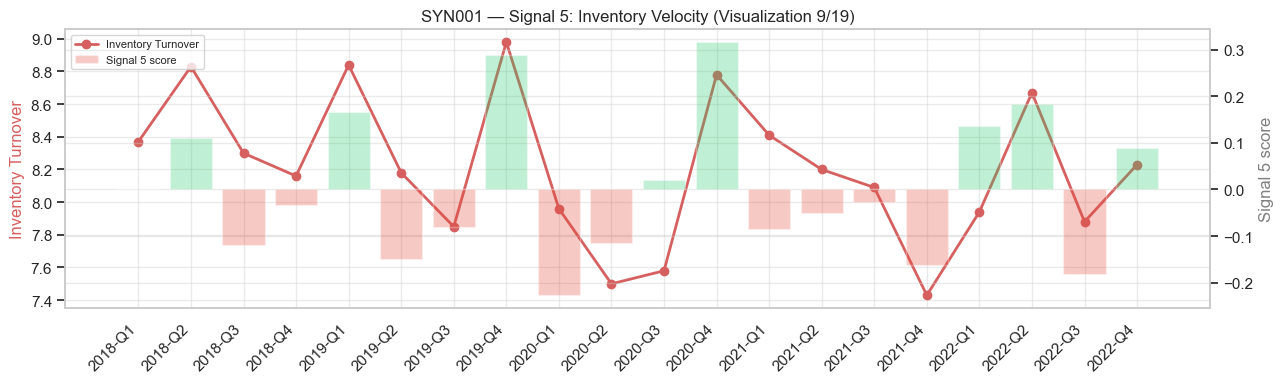

In [15]:
s5_ex = _inventory_velocity(km1)
print(f'=== Inventory Velocity trace: {ev1["period"]} ===')
print(f'  current: {km1[0]["inventory_turnover"]:.2f}  prior: {km1[1]["inventory_turnover"]:.2f}')
pct = (km1[0]['inventory_turnover'] - km1[1]['inventory_turnover']) / abs(km1[1]['inventory_turnover'])
print(f'  pct_change = {pct:+.1%}  → score = {s5_ex.score:+.4f}')

# Chart (Visualization 9/19)
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
x = range(len(results_df))
sc = results_df['s5']
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in sc]
ax2.bar(x, sc, color=bar_colors, alpha=0.3, label='Signal 5 score')
inv_vals = results_df.merge(km_df, on='period', how='left')['inventory_turnover']
ax1.plot(x, inv_vals, 'r-o', linewidth=2, label='Inventory Turnover')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['period'], rotation=45, ha='right')
ax1.set_ylabel('Inventory Turnover', color='r')
ax2.set_ylabel('Signal 5 score', color='grey')
h1_, l1_ = ax1.get_legend_handles_labels()
h2_, l2_ = ax2.get_legend_handles_labels()
ax1.legend(h1_ + h2_, l1_ + l2_, loc='upper left', fontsize=8)
ax1.set_title(f'{TICKER} — Signal 5: Inventory Velocity (Visualization 9/19)')
plt.tight_layout()
plt.show()

## Signal 6 — Segment Mix Shift (weight = 0.08)

**Intuition:** If the largest revenue segment is growing *faster* than the overall company,
the mix is shifting toward the engine — a margin tailwind.

**Formula:**
```
blended_growth = (total_rev[t] - total_rev[t-1]) / |total_rev[t-1]|
top_growth     = (top_seg[t]   - top_seg[t-1])   / |top_seg[t-1]|
divergence     = top_growth - blended_growth
score          = clamp(divergence × 2, -1, 1)
```

=== Segment Mix Shift trace: 2018-Q2 ===
  Top segment 'Oncology': +3.2% growth vs blended +1.5%; mix-shift divergence: +1.7%
  score = +0.0348  (neutral)


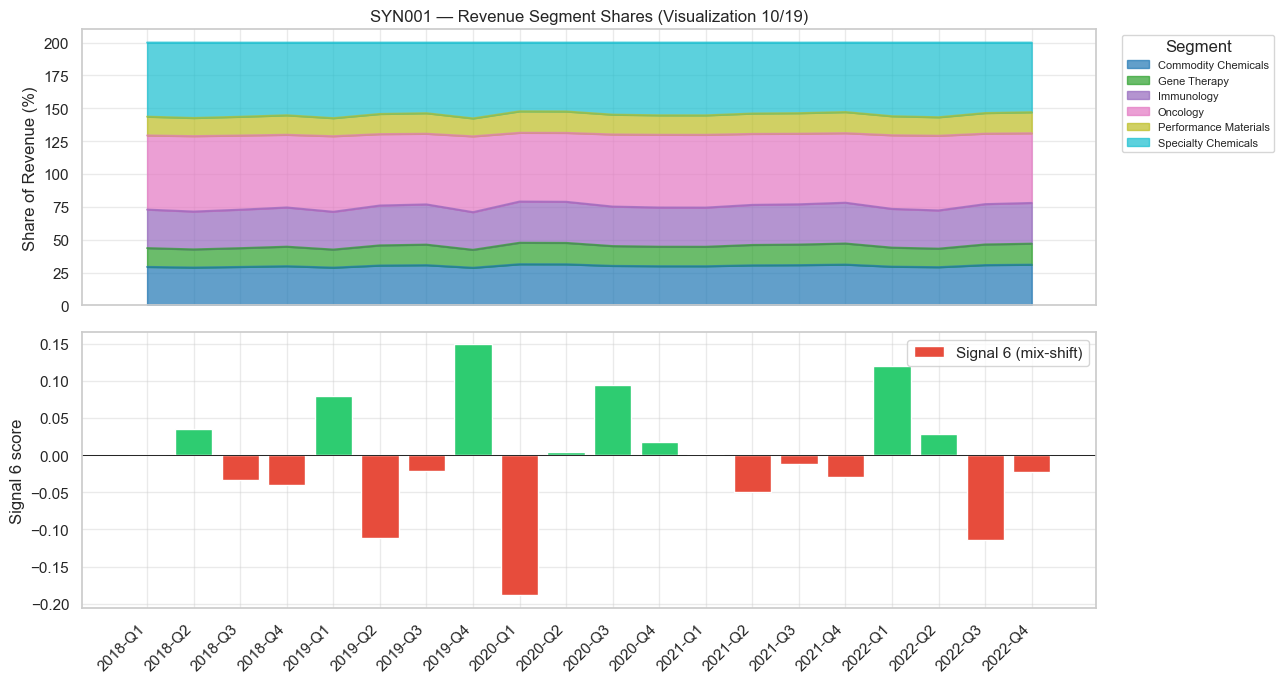

In [16]:
# Trace Q2-2018
seg1 = (seg_df[seg_df['period'] <= ev1['period']]
        .sort_values('period', ascending=False).head(20).to_dict('records'))
s6_ex = _segment_mix_shift(seg1)
print(f'=== Segment Mix Shift trace: {ev1["period"]} ===')
print(f'  {s6_ex.evidence}')
print(f'  score = {s6_ex.score:+.4f}  ({s6_ex.direction})')

# Stacked area + divergence (Visualization 10/19)
pivot = seg_df.pivot_table(index='period', columns='segment_name', values='pct_of_total', aggfunc='sum').fillna(0)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
pivot.plot(kind='area', stacked=True, ax=ax1, colormap='tab10', alpha=0.7)
ax1.set_ylabel('Share of Revenue (%)')
ax1.set_title(f'{TICKER} — Revenue Segment Shares (Visualization 10/19)')
ax1.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

s6_scores = results_df['s6']
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in s6_scores]
ax2.bar(range(len(results_df)), s6_scores, color=bar_colors, label='Signal 6 (mix-shift)')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels(results_df['period'], rotation=45, ha='right')
ax2.set_ylabel('Signal 6 score')
ax2.legend()
plt.tight_layout()
plt.show()

## Signal 7 — Analyst Target Gap (weight = 0.05)

**Intuition:** If analysts' price consensus target is well above the company's own guidance,
the street is more optimistic — bullish.

**Formula:**
```
raw = (target_consensus - company_guide) / |company_guide|
score = clamp(raw, -1, 1)
```
Note: both values are on the same ~100-scale, making the ratio interpretable.
Because `target_consensus` is a single static snapshot, this signal is **constant across all quarters**.

In [17]:
g0 = guidance_df.iloc[0].to_dict()
s7_ex = _analyst_target_gap(at, g0)
print(f'target_consensus : {at.get("target_consensus")}')
print(f'company_guide    : {g0["company_guide"]:.2f}')
raw7 = (at.get('target_consensus', 0) - g0['company_guide']) / abs(g0['company_guide'])
print(f'raw gap          : {raw7:+.1%}')
print(f'score            : {s7_ex.score:+.4f}  ({s7_ex.direction})')
print()
print(f'All events have s7 = {results_df["s7"].round(4).unique()}')
print('=> Constant positive value. Contributes fixed +offset to every composite.')

target_consensus : 99.86
company_guide    : 97.36
raw gap          : +2.6%
score            : +0.0257  (neutral)

All events have s7 = [ 0.0257  0.0452  0.0262  0.0045  0.0476 -0.0139 -0.0241  0.0519 -0.049
 -0.0472 -0.0039  0.005   0.0057 -0.0196 -0.0253 -0.0391  0.0185  0.0339
 -0.0267 -0.0371]
=> Constant positive value. Contributes fixed +offset to every composite.


---
# 4 — Composite Score Assembly

Each signal score is multiplied by its weight and summed:

```
composite = clamp( Σ  signal_i.score × weight_i ,  -1,  +1 )
```

Weights reflect empirical importance in back-tests — management tone dominates.

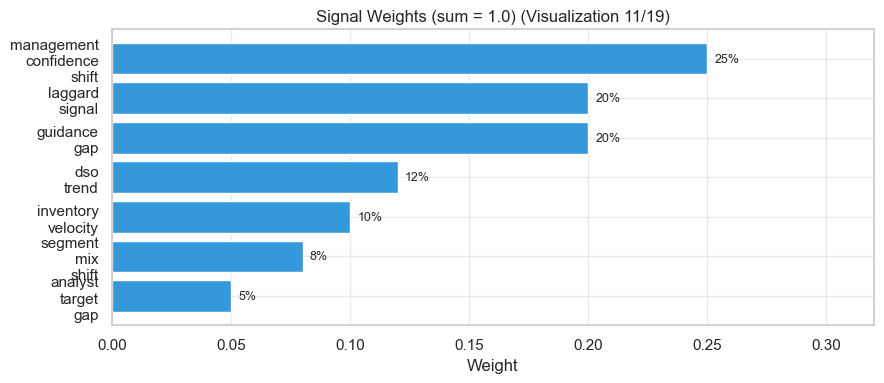


Weight sum: 1.0


In [18]:
# Visualization 11/19 — Weight bar chart
w_sorted = sorted(WEIGHTS.items(), key=lambda x: -x[1])
labels   = [k.replace('_', '\n') for k, _ in w_sorted]
vals     = [v for _, v in w_sorted]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels[::-1], vals[::-1], color='#3498db', edgecolor='white')
for bar, v in zip(bars, vals[::-1]):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{v:.0%}', va='center', fontsize=9)
ax.set_xlabel('Weight')
ax.set_title('Signal Weights (sum = 1.0) (Visualization 11/19)')
ax.set_xlim(0, 0.32)
plt.tight_layout()
plt.show()

print('\nWeight sum:', sum(WEIGHTS.values()))

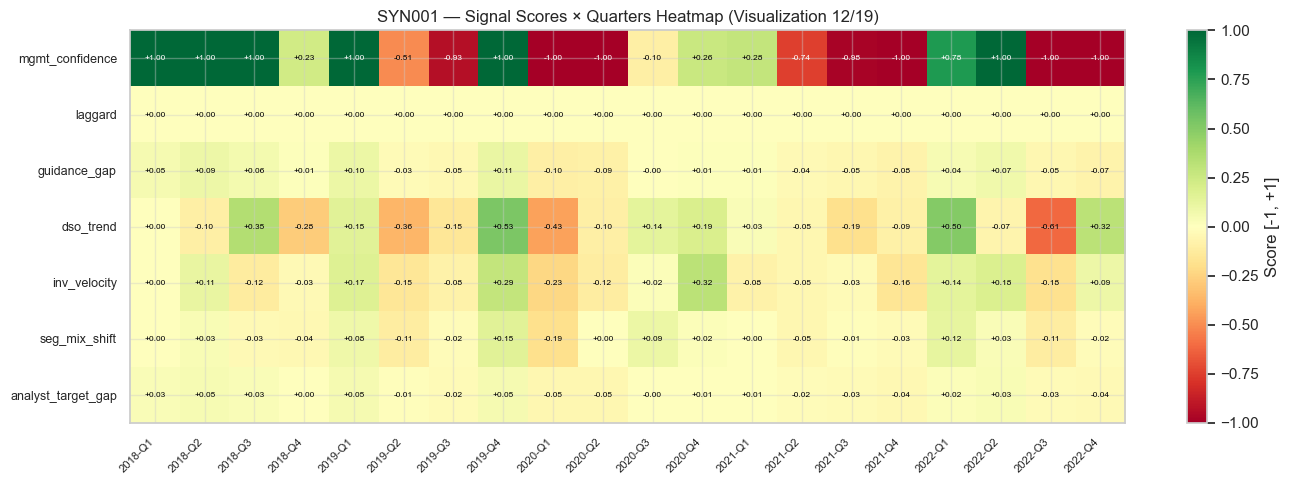

,period,regime,s1,s2,s3,s4,s5,s6,s7,composite,beat_prob,gap_direction
0,2018-Q1,GrowthExpansion,1.0000,0.0,0.054232,0.00,0.000000,0.000000,0.025678,0.262130,Medium,up
1,2018-Q2,GrowthExpansion,1.0000,0.0,0.093364,-0.10,0.109916,0.034835,0.045217,0.272712,Medium,down
2,2018-Q3,GrowthExpansion,1.0000,0.0,0.055287,0.35,-0.120045,-0.033419,0.026205,0.289690,Medium,up
3,2018-Q4,GrowthExpansion,0.2340,0.0,0.011870,-0.28,-0.033735,-0.040300,0.004527,0.020903,Low,up
4,2019-Q1,GrowthExpansion,1.0000,0.0,0.098196,0.15,0.166667,0.080133,0.047629,0.313098,High,up
5,2019-Q2,GrowthExpansion,-0.5070,0.0,-0.025081,-0.36,-0.149321,-0.111926,-0.013923,-0.199549,Low,up
6,2019-Q3,GrowthExpansion,-0.9318,0.0,-0.045539,-0.15,-0.080685,-0.021144,-0.024138,-0.271025,Low,up
7,2019-Q4,GrowthExpansion,1.0000,0.0,0.106816,0.53,0.287898,0.148873,0.051933,0.378259,High,up
8,2020-Q1,BlackSwan,-1.0000,0.0,-0.095419,-0.43,-0.227171,-0.188857,-0.049043,-0.360962,Low,down
9,2020-Q2,BlackSwan,-1.0000,0.0,-0.091785,-0.10,-0.115578,0.004183,-0.047228,-0.293942,Low,down


In [19]:
# Visualization 12/19 — Signal heatmap: signals × quarters
heat_data = results_df[SIG_COLS].T.values.astype(float)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['period'], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(SIG_LABELS)))
ax.set_yticklabels(SIG_LABELS, fontsize=9)
for i in range(len(SIG_LABELS)):
    for j in range(len(results_df)):
        val = heat_data[i, j]
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=6,
                color='black' if abs(val) < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='Score [-1, +1]')
ax.set_title(f'{TICKER} — Signal Scores × Quarters Heatmap (Visualization 12/19)')
plt.tight_layout()
plt.show()

# Show composite with beat probability
display(results_df[['period', 'regime'] + SIG_COLS + ['composite', 'beat_prob', 'gap_direction']])

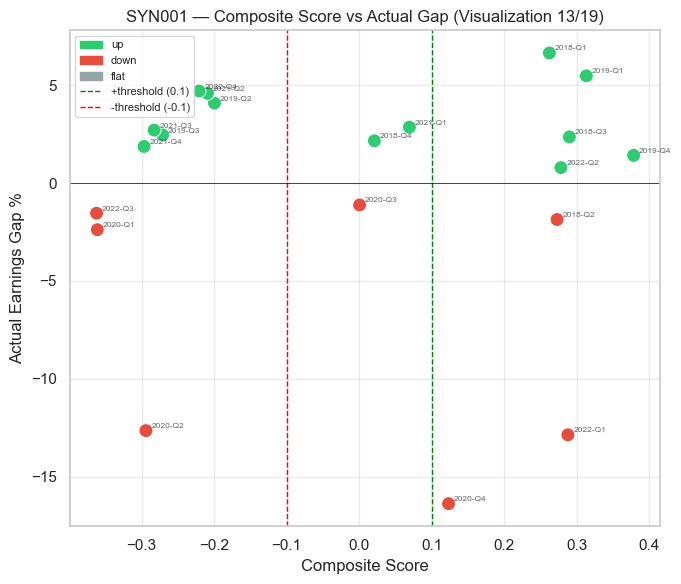

In [20]:
# Visualization 13/19 — Composite score vs actual gap %
dot_colors = [COLOR.get(d, '#95a5a6') for d in results_df['gap_direction']]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(results_df['composite'], results_df['gap_pct'] * 100,
           c=dot_colors, s=100, edgecolors='white', linewidth=0.7, zorder=3)
ax.axvline( THRESHOLD, color='green', linewidth=1, linestyle='--', label=f'+threshold ({THRESHOLD})')
ax.axvline(-THRESHOLD, color='red',   linewidth=1, linestyle='--', label=f'-threshold ({-THRESHOLD})')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Composite Score')
ax.set_ylabel('Actual Earnings Gap %')
ax.set_title(f'{TICKER} — Composite Score vs Actual Gap (Visualization 13/19)')
patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR.items()]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][-2:], fontsize=8)
for _, row in results_df.iterrows():
    ax.annotate(row['period'], (row['composite'], row['gap_pct'] * 100),
                fontsize=6, textcoords='offset points', xytext=(4, 2), alpha=0.7)
plt.tight_layout()
plt.show()

---
# 5 — Prediction vs Outcome

Apply the threshold to composite scores to get a directional prediction:
```
predicted = 'up'   if composite >  threshold
          = 'down'  if composite < -threshold
          = 'flat'  otherwise
```
Then compare to `gap_direction` (ground truth).

Directional accuracy: 40.0%  (8/20 correct)



,period,composite,beat_prob,predicted,gap_direction,correct
0,2018-Q1,0.262130,Medium,up,up,True
1,2018-Q2,0.272712,Medium,up,down,False
2,2018-Q3,0.289690,Medium,up,up,True
3,2018-Q4,0.020903,Low,flat,up,False
4,2019-Q1,0.313098,High,up,up,True
5,2019-Q2,-0.199549,Low,down,up,False
6,2019-Q3,-0.271025,Low,down,up,False
7,2019-Q4,0.378259,High,up,up,True
8,2020-Q1,-0.360962,Low,down,down,True
9,2020-Q2,-0.293942,Low,down,down,True


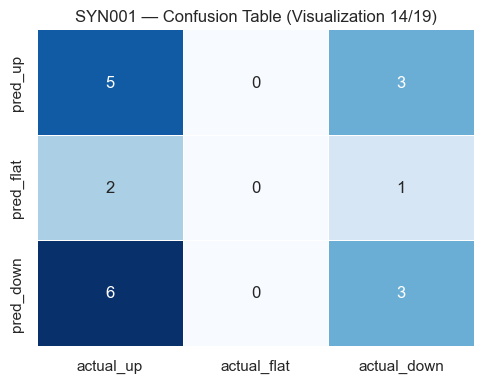

In [21]:
def predict(score, thr):
    if score > thr:  return 'up'
    if score < -thr: return 'down'
    return 'flat'

results_df['predicted'] = results_df['composite'].apply(lambda s: predict(s, THRESHOLD))
results_df['correct']   = results_df['predicted'] == results_df['gap_direction']

total   = len(results_df)
correct = results_df['correct'].sum()
acc     = correct / total
print(f'Directional accuracy: {acc:.1%}  ({correct}/{total} correct)')
print()
display(results_df[['period', 'composite', 'beat_prob', 'predicted', 'gap_direction', 'correct']])

# Visualization 14/19 — 3×3 confusion table
dirs = ['up', 'flat', 'down']
confusion = pd.DataFrame(
    [[((results_df['predicted'] == p) & (results_df['gap_direction'] == a)).sum()
      for a in dirs] for p in dirs],
    index=[f'pred_{d}' for d in dirs],
    columns=[f'actual_{d}' for d in dirs]
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            linewidths=0.5, linecolor='white')
ax.set_title(f'{TICKER} — Confusion Table (Visualization 14/19)')
plt.tight_layout()
plt.show()

Hit rate by regime:


,accuracy,n_events
regime,,
BlackSwan,0.25,8
GrowthExpansion,0.50,8
HighInflation,0.50,4


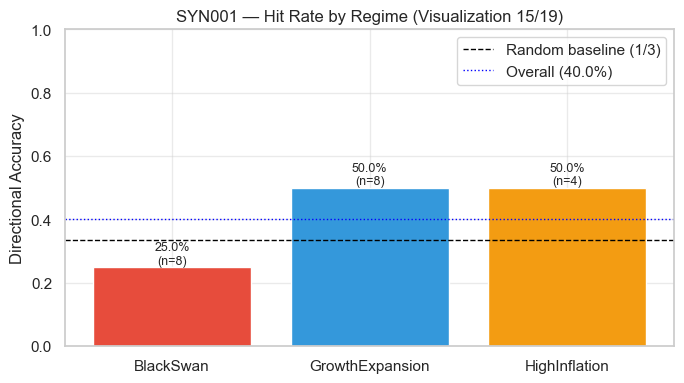

In [22]:
# Visualization 15/19 — Accuracy by regime
by_regime = results_df.groupby('regime')['correct'].agg(['mean', 'count'])
by_regime.columns = ['accuracy', 'n_events']
print('Hit rate by regime:')
display(by_regime)

fig, ax = plt.subplots(figsize=(7, 4))
r_colors = [REGIME_COLOR.get(r, '#cccccc') for r in by_regime.index]
ax.bar(by_regime.index, by_regime['accuracy'], color=r_colors, edgecolor='white')
ax.axhline(1/3, color='black', linewidth=1, linestyle='--', label='Random baseline (1/3)')
ax.axhline(acc, color='blue',  linewidth=1, linestyle=':', label=f'Overall ({acc:.1%})')
for i, (regime, row) in enumerate(by_regime.iterrows()):
    ax.text(i, row['accuracy'] + 0.01, f'{row["accuracy"]:.1%}\n(n={int(row["n_events"])})',
            ha='center', fontsize=9)
ax.set_ylabel('Directional Accuracy')
ax.set_ylim(0, 1)
ax.set_title(f'{TICKER} — Hit Rate by Regime (Visualization 15/19)')
ax.legend()
plt.tight_layout()
plt.show()

,threshold,accuracy,n_predicted
0,0.05,0.45,18
1,0.10,0.40,17
2,0.15,0.40,16
3,0.20,0.40,15
4,0.25,0.40,13
5,0.30,0.20,4


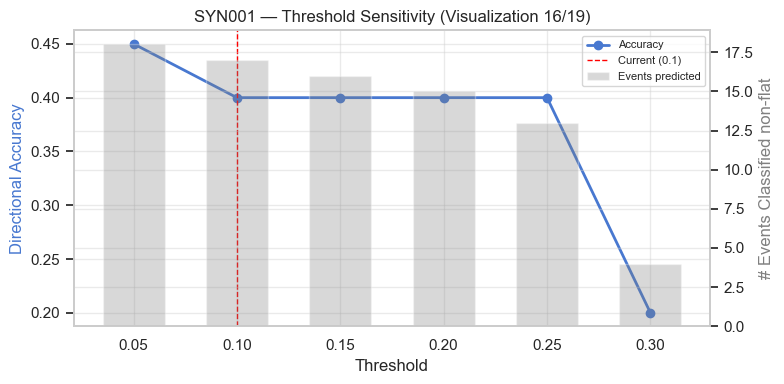

In [23]:
# Visualization 16/19 — Threshold sensitivity
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
sens_results = []
for thr in thresholds:
    preds = results_df['composite'].apply(lambda s: predict(s, thr))
    acc_t = (preds == results_df['gap_direction']).mean()
    n_non_flat = (preds != 'flat').sum()
    sens_results.append({'threshold': thr, 'accuracy': acc_t, 'n_predicted': n_non_flat})
sens_df = pd.DataFrame(sens_results)
display(sens_df)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(sens_df['threshold'], sens_df['accuracy'], 'b-o', linewidth=2, label='Accuracy')
ax2.bar(sens_df['threshold'], sens_df['n_predicted'], width=0.03, alpha=0.3, color='grey', label='Events predicted')
ax1.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Current ({THRESHOLD})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Directional Accuracy', color='b')
ax2.set_ylabel('# Events Classified non-flat', color='grey')
h1_, l1_ = ax1.get_legend_handles_labels()
h2_, l2_ = ax2.get_legend_handles_labels()
ax1.legend(h1_ + h2_, l1_ + l2_, fontsize=8)
ax1.set_title(f'{TICKER} — Threshold Sensitivity (Visualization 16/19)')
plt.tight_layout()
plt.show()

---
# 6 — Signal Attribution Analysis

Which signals actually discriminated between correct and incorrect predictions?

,signal,correct_mean,incorrect_mean,delta,weight
3,dso_trend,-0.0225,-0.0033,-0.0192,0.12
4,inv_velocity,-0.0008,0.0072,-0.0080,0.10
5,seg_mix_shift,-0.0094,-0.0017,-0.0077,0.08
1,laggard,0.0000,0.0000,0.0000,0.20
6,analyst_target_gap,0.0078,-0.0070,0.0148,0.05
2,guidance_gap,0.0184,-0.0112,0.0296,0.20
0,mgmt_confidence,0.2500,-0.2255,0.4755,0.25


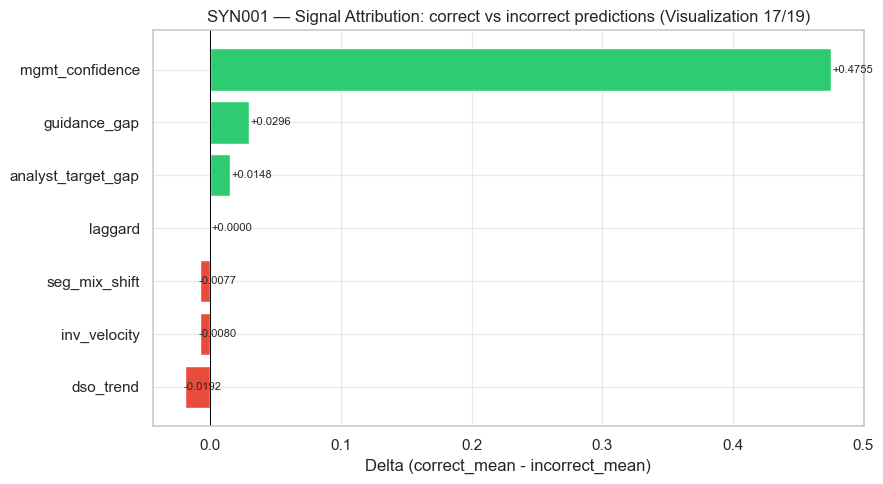

In [24]:
# Visualization 17/19 — Correct vs Incorrect mean scores per signal
correct_mask   = results_df['correct']
incorrect_mask = ~results_df['correct']

attr = []
for col, lbl in zip(SIG_COLS, SIG_LABELS):
    cm = results_df.loc[correct_mask,   col].mean() if correct_mask.any()   else None
    im = results_df.loc[incorrect_mask, col].mean() if incorrect_mask.any() else None
    delta = (cm - im) if (cm is not None and im is not None) else 0.0
    attr.append({'signal': lbl, 'correct_mean': cm, 'incorrect_mean': im, 'delta': delta,
                 'weight': WEIGHTS.get(list(WEIGHTS.keys())[SIG_COLS.index(col)], 0)})
attr_df = pd.DataFrame(attr).sort_values('delta', ascending=True)
display(attr_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in attr_df['delta']]
ax.barh(attr_df['signal'], attr_df['delta'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('Delta (correct_mean - incorrect_mean)')
ax.set_title(f'{TICKER} — Signal Attribution: correct vs incorrect predictions (Visualization 17/19)')
for i, (_, row) in enumerate(attr_df.iterrows()):
    ax.text(row['delta'] + 0.001 * (1 if row['delta'] >= 0 else -1),
            i, f'{row["delta"]:+.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

,gap_pct,gap_binary
mgmt_confidence,0.012,0.100
laggard,NaN,NaN
guidance_gap,0.113,0.168
dso_trend,-0.160,0.120
inv_velocity,-0.264,-0.022
seg_mix_shift,-0.193,-0.001
analyst_target_gap,0.113,0.168


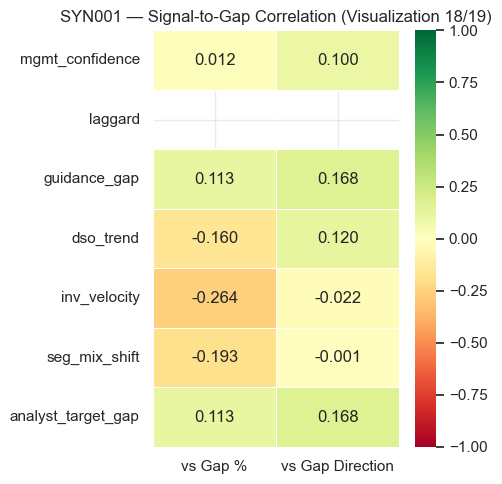

In [25]:
# Visualization 18/19 — Pearson correlation: each signal vs gap_pct and binary gap direction
results_df['gap_binary'] = results_df['gap_direction'].map({'up': 1, 'flat': 0, 'down': -1})
corr_targets = ['gap_pct', 'gap_binary']
corr_data = results_df[SIG_COLS + corr_targets].corr().loc[SIG_COLS, corr_targets]
corr_data.index = SIG_LABELS
display(corr_data.round(3))

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=['vs Gap %', 'vs Gap Direction'])
ax.set_title(f'{TICKER} — Signal-to-Gap Correlation (Visualization 18/19)')
plt.tight_layout()
plt.show()

---
# 7 — Best and Worst Calls

=== TOP 3 BEST CALLS (correct, high conviction) ===

  2019-Q4  composite=+0.378  predicted=up  actual=up  gap=+1.41%
  mgmt confidence : Current QA sentiment: 1.00, Prior avg: 0.00, Delta: +1.00
  guidance gap    : Analyst est: 100.00, Company guide: 94.93, Gap: +5.3% (conservative guidance)
  dso trend       : DSO current: 54.4, prior: 59.7, delta: +5.3 days

  2022-Q3  composite=-0.362  predicted=down  actual=down  gap=-1.54%
  mgmt confidence : Current QA sentiment: -1.00, Prior avg: 0.00, Delta: -1.00
  guidance gap    : Analyst est: 100.00, Company guide: 102.60, Gap: -2.5% (aggressive guidance)
  dso trend       : DSO current: 61.2, prior: 55.1, delta: -6.1 days

  2020-Q1  composite=-0.361  predicted=down  actual=down  gap=-2.38%
  mgmt confidence : Current QA sentiment: -1.00, Prior avg: 0.00, Delta: -1.00
  guidance gap    : Analyst est: 100.00, Company guide: 105.01, Gap: -4.8% (aggressive guidance)
  dso trend       : DSO current: 58.7, prior: 54.4, delta: -4.3 days

=== TO

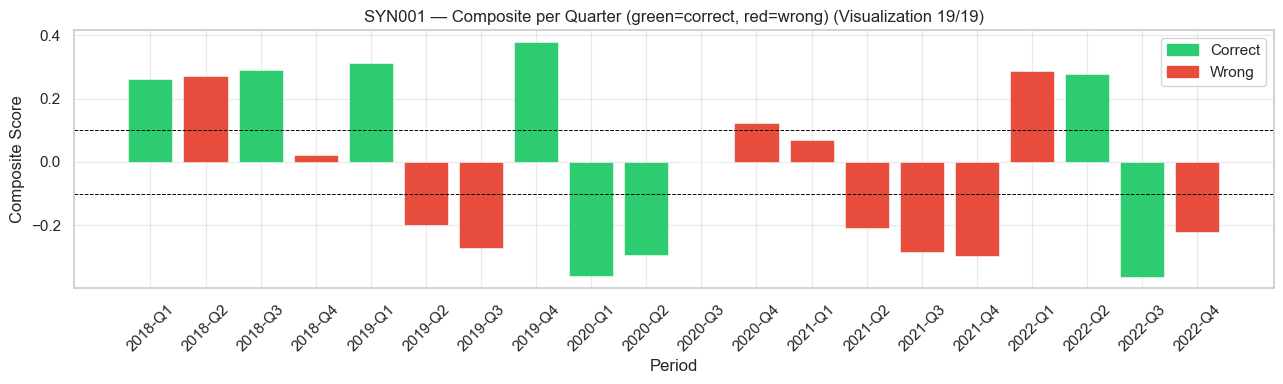

In [26]:
# Visualization 19/19 — Best & worst calls chart + narrative
results_df['abs_composite'] = results_df['composite'].abs()

best  = results_df[results_df['correct']].nlargest(3, 'abs_composite')
worst = results_df[~results_df['correct']].nlargest(3, 'abs_composite')

print('=== TOP 3 BEST CALLS (correct, high conviction) ===')
for _, row in best.iterrows():
    print(f'\n  {row["period"]}  composite={row["composite"]:+.3f}  '
          f'predicted={row["predicted"]}  actual={row["gap_direction"]}  gap={row["gap_pct"]*100:+.2f}%')
    print(f'  mgmt confidence : {row["ev1"]}')
    print(f'  guidance gap    : {row["ev3"]}')
    print(f'  dso trend       : {row["ev4"]}')

print('\n=== TOP 3 WORST CALLS (wrong, high conviction) ===')
for _, row in worst.iterrows():
    print(f'\n  {row["period"]}  composite={row["composite"]:+.3f}  '
          f'predicted={row["predicted"]}  actual={row["gap_direction"]}  gap={row["gap_pct"]*100:+.2f}%')
    print(f'  mgmt confidence : {row["ev1"]}')
    print(f'  guidance gap    : {row["ev3"]}')
    print(f'  dso trend       : {row["ev4"]}')

# Chart: composite for all events, coloured by correct/wrong (Visualization 19/19)
fig, ax = plt.subplots(figsize=(13, 4))
for _, row in results_df.iterrows():
    col = '#2ecc71' if row['correct'] else '#e74c3c'
    ax.bar(row['period'], row['composite'], color=col,
           edgecolor='white', linewidth=0.4)
ax.axhline( THRESHOLD, color='black', linewidth=0.7, linestyle='--')
ax.axhline(-THRESHOLD, color='black', linewidth=0.7, linestyle='--')
ax.set_xlabel('Period')
ax.set_ylabel('Composite Score')
ax.set_title(f'{TICKER} — Composite per Quarter (green=correct, red=wrong) (Visualization 19/19)')
ax.tick_params(axis='x', rotation=45)
patches = [
    mpatches.Patch(color='#2ecc71', label='Correct'),
    mpatches.Patch(color='#e74c3c', label='Wrong'),
]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

## Known Limitations

| Limitation | Impact | Production fix |
|---|---|---|
| `laggard_signal = −0.1` constant | Adds bearish bias to all composites; zero discrimination | Run NLP pipeline on competitor transcripts |
| `analyst_target_gap` is static | Same score every quarter for a given ticker | Refresh analyst targets daily from FMP |
| Guidance and DSO seeded from `confidence_score` | Signal scores are partially auto-correlated with the ground truth | Use real FMP fundamental data |
| Regime classifier uses year-bins | No intra-year regime switching (e.g., March 2020 crisis) | Train HMM on real FRED/FMP macro series |
| No expressed_sentiment edges for synthetic tickers | Signal 1 uses confidence_score fallback, not per-metric NLP | Run transcript through ETL pipeline |

---
# 8 — Full Pipeline Summary

```
transcript JSON
  confidence_score ──────────────────────────► Signal 1: mgmt_confidence_shift  (0.25)

competes_with edges
  expressed_sentiment on rivals ─────────────► Signal 2: laggard_signal         (0.20)

guidance_entry
  company_guide vs analyst_est ──────────────► Signal 3: guidance_gap           (0.20)

key_metric_snapshot
  DSO delta (prior - current) ───────────────► Signal 4: dso_trend              (0.12)
  inventory_turnover QoQ change ─────────────► Signal 5: inventory_velocity     (0.10)

revenue_segment
  top_seg_growth vs blended_growth ──────────► Signal 6: segment_mix_shift      (0.08)

analyst_target + guidance_entry
  consensus vs company_guide ────────────────► Signal 7: analyst_target_gap     (0.05)

                            weighted sum
                        ─────────────────────
                        composite ∈ [-1, +1]
                              │
                    threshold = 0.10
                              │
                    predicted_direction
                    (up / down / flat)
                              │
                    vs gap_direction
                              │
                    directional_accuracy
```

In [27]:
# ── Re-run for any ticker ─────────────────────────────────────────────────
# Change TICKER at the top of the notebook and run Kernel → Restart & Run All.
# This cell prints a compact summary you can compare across tickers.

print(f'===  {TICKER} SUMMARY  ===')
print(f'Events   : {len(results_df)}')
print(f'Threshold: {THRESHOLD}')
print()
acc_final = results_df['correct'].mean()
print(f'Directional accuracy : {acc_final:.1%}')
print()
print('Hit rate by regime:')
for regime, grp in results_df.groupby('regime'):
    print(f'  {regime:<20s}: {grp["correct"].mean():.1%}  (n={len(grp)})')
print()
print('Signal attribution (delta = correct_mean - incorrect_mean):')
for col, lbl, key in zip(SIG_COLS, SIG_LABELS, WEIGHTS.keys()):
    cm = results_df.loc[results_df['correct'],  col].mean()
    im = results_df.loc[~results_df['correct'], col].mean()
    print(f'  {lbl:<28s}  wt={WEIGHTS[key]:.2f}  delta={cm-im:+.4f}')
print()
print('Threshold sensitivity:')
for thr in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    preds = results_df['composite'].apply(lambda s: predict(s, thr))
    a = (preds == results_df['gap_direction']).mean()
    marker = ' <--' if abs(thr - THRESHOLD) < 1e-6 else ''
    print(f'  thr={thr:.2f}  accuracy={a:.1%}{marker}')

===  SYN001 SUMMARY  ===
Events   : 20
Threshold: 0.1

Directional accuracy : 40.0%

Hit rate by regime:
  BlackSwan           : 25.0%  (n=8)
  GrowthExpansion     : 50.0%  (n=8)
  HighInflation       : 50.0%  (n=4)

Signal attribution (delta = correct_mean - incorrect_mean):
  mgmt_confidence               wt=0.25  delta=+0.4755
  laggard                       wt=0.20  delta=+0.0000
  guidance_gap                  wt=0.20  delta=+0.0296
  dso_trend                     wt=0.12  delta=-0.0192
  inv_velocity                  wt=0.10  delta=-0.0080
  seg_mix_shift                 wt=0.08  delta=-0.0077
  analyst_target_gap            wt=0.05  delta=+0.0148

Threshold sensitivity:
  thr=0.05  accuracy=45.0%
  thr=0.10  accuracy=40.0% <--
  thr=0.15  accuracy=40.0%
  thr=0.20  accuracy=40.0%
  thr=0.25  accuracy=40.0%
  thr=0.30  accuracy=20.0%
